## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## 2. Load the Dataset

In [2]:
df = pd.read_csv("../data/processed/amazon_reviews_clean.csv")

print(df.shape)
df.head()

(34626, 12)


,name,brand,categories,reviews.rating,reviews.text,reviews.title,reviews.numHelpful,reviews.doRecommend,sentiment,id,keys,asins
0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",5.0,This product so far has not disappointed. My c...,Kindle,0.0,True,Positive,AVqkIhwDv8e3D1O-lebb,"841667104676,amazon/53004484,amazon/b01ahb9cn2...",B01AHB9CN2
1,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",5.0,great for beginner or experienced person. Boug...,very fast,0.0,True,Positive,AVqkIhwDv8e3D1O-lebb,"841667104676,amazon/53004484,amazon/b01ahb9cn2...",B01AHB9CN2
2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",5.0,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,0.0,True,Positive,AVqkIhwDv8e3D1O-lebb,"841667104676,amazon/53004484,amazon/b01ahb9cn2...",B01AHB9CN2
3,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",4.0,I've had my Fire HD 8 two weeks now and I love...,Good!!!,0.0,True,Positive,AVqkIhwDv8e3D1O-lebb,"841667104676,amazon/53004484,amazon/b01ahb9cn2...",B01AHB9CN2
4,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",5.0,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,0.0,True,Positive,AVqkIhwDv8e3D1O-lebb,"841667104676,amazon/53004484,amazon/b01ahb9cn2...",B01AHB9CN2


In [3]:
df.info()

df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34626 entries, 0 to 34625
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   name                 27867 non-null  object 
 1   brand                34626 non-null  object 
 2   categories           34626 non-null  object 
 3   reviews.rating       34626 non-null  float64
 4   reviews.text         34626 non-null  object 
 5   reviews.title        34620 non-null  object 
 6   reviews.numHelpful   34131 non-null  float64
 7   reviews.doRecommend  34066 non-null  object 
 8   sentiment            34626 non-null  object 
 9   id                   34626 non-null  object 
 10  keys                 34626 non-null  object 
 11  asins                34624 non-null  object 
dtypes: float64(2), object(10)
memory usage: 3.2+ MB


name                   6759
brand                     0
categories                0
reviews.rating            0
reviews.text              0
reviews.title             6
reviews.numHelpful      495
reviews.doRecommend     560
sentiment                 0
id                        0
keys                      0
asins                     2
dtype: int64

## 3. Feature Selection

The objective is to group products into meaningful meta-categories based on textual similarity and product characteristics. Therefore, only descriptive variables are retained while identifiers and review metadata are excluded.  

In [4]:
cluster_df = df[
    [
        "name",
        "categories",
    ]
].copy()

In [5]:
cluster_df["name"] = cluster_df["name"].fillna("")

In [6]:
cluster_df["cluster_text"] = (
    cluster_df["name"]
    + " "
    + cluster_df["categories"]
    + " "
)

## 4. Text Preprocessing
    - Build the Clustering Corpus

K-Means cannot work directly with text data. Therefore, the product information is converted into a numerical representation using TF-IDF (Term Frequency–Inverse Document Frequency).

TF-IDF assigns higher importance to words that are frequent within a document but uncommon across the dataset, helping distinguish different product types.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [8]:
tfidf = TfidfVectorizer(
    stop_words="english",
    lowercase=True,
    min_df=5,
    max_df=0.90
)


+ stop_words="english" → removes common words like the, is, and.
+ lowercase=True → treats "Tablet" and "tablet" as the same word.
+ min_df=5 → ignores words appearing in fewer than 5 documents (reduces noise).
+ max_df=0.90 → ignores extremely common words.


## 5. TF-IDF Vectorization

In [9]:
X_tfidf = tfidf.fit_transform(cluster_df["cluster_text"])

print(X_tfidf.shape)

(34626, 209)


In [10]:
print(f"Vocabulary size: {len(tfidf.get_feature_names_out()):,}")

Vocabulary size: 209


In [11]:
feature_names = tfidf.get_feature_names_out()

print(feature_names[:50])

['10' '16' '16gb' '1st' '2014' '2015' '2016' '2nd' '300' '32' '3g' '4gb'
 '4th' '5th' '5w' '6th' '8in' '9w' 'accessories' 'accs' 'adapter'
 'adapters' 'adaptive' 'alarms' 'alexa' 'aluminum' 'amazon' 'android'
 'angle' 'assistant' 'assistants' 'audio' 'automation' 'b018szt3bk' 'bags'
 'batteries' 'black' 'blue' 'bluetooth' 'book' 'books' 'brand' 'brands'
 'built' 'business' 'cable' 'cables' 'case' 'cases' 'categories']


## 6. 6. Dimensionality Reduction (Truncated SVD)

TF-IDF creates a very high-dimensional and sparse representation of the text. High dimensionality can reduce the effectiveness and efficiency of K-Means clustering.

To obtain a compact representation while preserving the main semantic information, Truncated Singular Value Decomposition (Truncated SVD), also known as Latent Semantic Analysis (LSA), is applied.

In [12]:
from sklearn.decomposition import TruncatedSVD

In [13]:
svd = TruncatedSVD(
    n_components=100,
    random_state=42
)

X_reduced = svd.fit_transform(X_tfidf)

In [14]:
print("Original shape:", X_tfidf.shape)
print("Reduced shape:", X_reduced.shape)

Original shape: (34626, 209)
Reduced shape: (34626, 100)


## 7. Selecting the Number of Clusters

The Elbow Method and the Silhouette Score were used to evaluate different values of **k**.

Although lower values of **k** produced simpler groupings, **k = 6** was selected for this experiment to explore a more detailed segmentation of the Amazon product catalog while remaining within the recommended range of **4–6 meta-categories**.

This configuration allows large product families, such as Fire Tablets, to be divided into more specific subgroups while preserving the separation of the remaining product categories.

In [15]:
#Evaluate K = 2–10
inertia = []
silhouette = []

k_values = range(2, 11)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X_reduced)

    inertia.append(kmeans.inertia_)

    silhouette.append(
        silhouette_score(X_reduced, labels)
    )

####  - Elbow Method

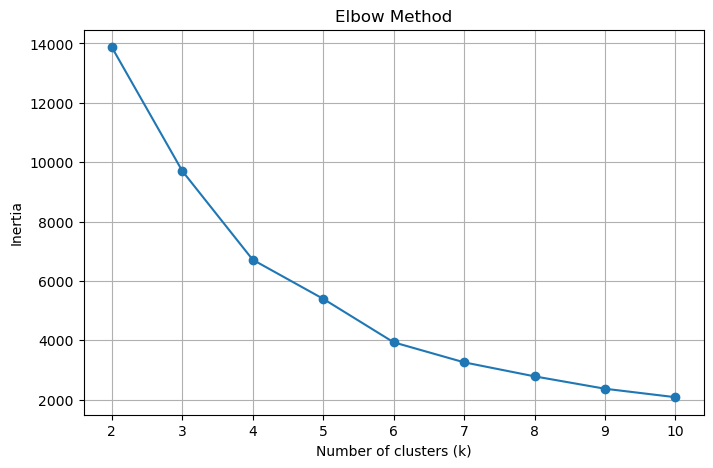

In [16]:
#Elbow Plot
plt.figure(figsize=(8,5))

plt.plot(k_values, inertia, marker="o")

plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.grid(True)

plt.show()

#### - Silhouette Analysis

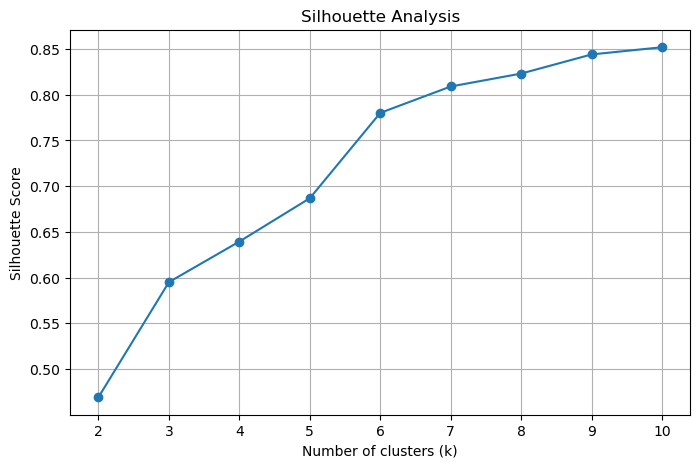

In [17]:
#Silhouette Plot
plt.figure(figsize=(8,5))

plt.plot(k_values, silhouette, marker="o")

plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.grid(True)

plt.show()

## 7. Choosing the Number of Clusters

Two complementary evaluation methods were used to determine the appropriate number of clusters.

The **Elbow Method** shows a clear reduction in inertia up to **k = 6**, after which the improvement becomes more gradual. This suggests that six clusters provide a good balance between model complexity and cluster compactness.

Unlike the previous experiment that included review text, the **Silhouette Score** increases steadily as the number of clusters grows. This behavior is expected because the model is built using only **product names** and **product categories**, resulting in many identical product representations. Consequently, the silhouette score does not identify a single optimal value of **k**.

Based on the Elbow Method, the project requirements (4–6 meta-categories), and the objective of obtaining a more detailed segmentation of the Amazon product catalog, **k = 6** was selected as the final clustering solution.

## 8. Final K-Means Model

After evaluating different values of **k**, a final K-Means model with **6 clusters** was trained.

Each observation is represented using a TF-IDF vector built from the **product name** and **product category**. The trained model assigns every product review to one of six clusters, which are interpreted in the next section as high-level product families.

In [18]:
#8.1 Train the final model
kmeans = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=20
)

cluster_df["cluster"] = kmeans.fit_predict(X_tfidf)

cluster_df.head()

,name,categories,cluster_text,cluster
0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Electronics,iPad & Tablets,All Tablets,Fire Ta...","All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",4
1,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Electronics,iPad & Tablets,All Tablets,Fire Ta...","All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",4
2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Electronics,iPad & Tablets,All Tablets,Fire Ta...","All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",4
3,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Electronics,iPad & Tablets,All Tablets,Fire Ta...","All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",4
4,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Electronics,iPad & Tablets,All Tablets,Fire Ta...","All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",4


In [19]:
#8.2 Cluster sizes
cluster_df["cluster"].value_counts().sort_index()

cluster
0     1679
1     7262
2    10937
3     5056
4     2981
5     6711
Name: count, dtype: int64

## 9. Cluster Interpretation

Since K-Means produces numerical cluster labels without semantic meaning, each cluster is analyzed by inspecting its most frequent product names, product categories, and representative products.

This qualitative analysis allows meaningful names to be assigned to the discovered product groups.

In [21]:
# 9.1 Cluster Sizes
cluster_sizes = cluster_df["cluster"].value_counts().sort_index()

display(cluster_sizes)

cluster
0     1679
1     7262
2    10937
3     5056
4     2981
5     6711
Name: count, dtype: int64

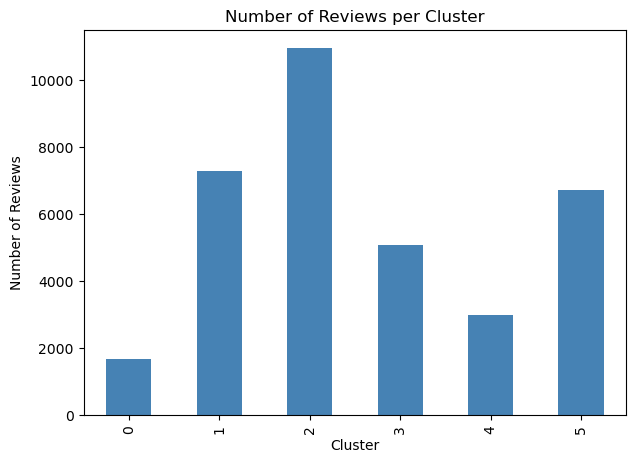

In [22]:
# 9.2 Visualize the distribution
plt.figure(figsize=(7,5))

cluster_df["cluster"].value_counts().sort_index().plot(
    kind="bar",
    color="steelblue"
)

plt.title("Number of Reviews per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Reviews")

plt.show()

In [39]:
# 9.3 Most common product names


for c in sorted(cluster_df["cluster"].unique()):

    print(f"\n{'='*60}")
    print(f"Cluster {c}")
    print('='*60)

    print(
        cluster_df.loc[
            cluster_df["cluster"] == c,
            "name"
        ].value_counts().head(10)
    )
    


Cluster 0
name
Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, Green Kid-Proof Case    1679
Name: count, dtype: int64

Cluster 1
name
Echo (White),,,\r\nEcho (White),,,                                                                                                                                                                                  2898
Amazon Fire Tv,,,\r\nAmazon Fire Tv,,,                                                                                                                                                                              2527
                                                                                                                                                                                                                    1314
Amazon - Amazon Tap Portable Bluetooth and Wi-Fi Speaker - Black,,,\r\nAmazon - Amazon Tap Portable Bluetooth and Wi-Fi Speaker - Black,,,                                                                         

### 9.4 Representative Products

To better understand the characteristics of each cluster, a small sample of unique products is displayed below. These examples help verify that the clustering groups together products belonging to the same product family.

In [40]:
for c in sorted(cluster_df["cluster"].unique()):

    print(f"\n{'='*60}")
    print(f"Cluster {c}")
    print("="*60)

    display(
        cluster_df.loc[
            cluster_df["cluster"] == c,
            ["name", "categories"]
        ]
        .drop_duplicates()
        .head(10)
    )


Cluster 0


,name,categories
15500,"Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16...","Computers/Tablets & Networking,Tablets & eBook..."
15748,"Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16...","Tablets,Fire Tablets,Computers & Tablets,All T..."



Cluster 1


,name,categories
21919,"Echo (White),,,\r\nEcho (White),,,","Stereos,Remote Controls,Amazon Echo,Audio Dock..."
24817,"Echo (White),,,\r\nFire Tablet, 7 Display, Wi-...","Stereos,Remote Controls,Amazon Echo,Audio Dock..."
24818,"Echo (Black),,,\r\nEcho (Black),,,","Stereos,Remote Controls,Amazon Echo,Audio Dock..."
24821,"Echo (Black),,,\r\nAmazon 9W PowerFast Officia...","Stereos,Remote Controls,Amazon Echo,Audio Dock..."
24822,Amazon 9W PowerFast Official OEM USB Charger a...,"Stereos,Remote Controls,Amazon Echo,Audio Dock..."
24858,Amazon Fire Hd 6 Standing Protective Case(4th ...,"Stereos,Remote Controls,Amazon Echo,Audio Dock..."
24864,Amazon Fire Hd 6 Standing Protective Case(4th ...,"Stereos,Remote Controls,Amazon Echo,Audio Dock..."
24865,Amazon 5W USB Official OEM Charger and Power A...,"Stereos,Remote Controls,Amazon Echo,Audio Dock..."
24872,"Amazon Fire Hd 10 Tablet, Wi-Fi, 16 Gb, Specia...","Stereos,Remote Controls,Amazon Echo,Audio Dock..."
25000,Amazon - Amazon Tap Portable Bluetooth and Wi-...,"Stereos,Remote Controls,Amazon Echo,Audio Dock..."



Cluster 2


...

,name,categories
29539,,"Back To College,College Electronics,College Tv..."



Cluster 4


,name,categories
0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Electronics,iPad & Tablets,All Tablets,Fire Ta..."
2886,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Tablets,Fire Tablets,Electronics,Computers,Com..."
3032,"Fire HD 8 Tablet with Alexa, 8 HD Display, 32 ...","Tablets,Fire Tablets,Electronics,Computers,Com..."
3044,"Fire HD 8 Tablet with Alexa, 8 HD Display, 32 ...","Tablets,Fire Tablets,Computers & Tablets,All T..."
14453,Amazon - Kindle Voyage - 4GB - Wi-Fi + 3G - Bl...,"Fire Tablets,Tablets,Computers & Tablets,All T..."
14454,"Fire HD 8 Tablet with Alexa, 8 HD Display, 16 ...","Fire Tablets,Tablets,Computers & Tablets,All T..."



Cluster 5


,name,categories
2814,Kindle Oasis E-reader with Leather Charging Co...,"eBook Readers,Kindle E-readers,Computers & Tab..."
2881,"Amazon Kindle Lighted Leather Cover,,,\r\nAmaz...","Electronics,eBook Readers & Accessories,Covers..."
2883,"Amazon Kindle Lighted Leather Cover,,,\r\nKind...","Electronics,eBook Readers & Accessories,Covers..."
2884,"Kindle Keyboard,,,\r\nKindle Keyboard,,,","Electronics,eBook Readers & Accessories,Covers..."
3046,Amazon 5W USB Official OEM Charger and Power A...,"Tablets,Fire Tablets,Computers & Tablets,All T..."
3058,Amazon 5W USB Official OEM Charger and Power A...,"Amazon Devices & Accessories,Amazon Device Acc..."
3246,"All-New Kindle E-reader - Black, 6 Glare-Free ...","Amazon Devices & Accessories,Amazon Device Acc..."
3458,"Amazon Kindle Fire Hd (3rd Generation) 8gb,,,\...","Amazon Devices & Accessories,Amazon Device Acc..."
3459,"Amazon Kindle Fire Hd (3rd Generation) 8gb,,,\...","Electronics,iPad & Tablets,All Tablets,Compute..."
3460,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...","Electronics,iPad & Tablets,All Tablets,Compute..."


### 9.5 Assigning Cluster Labels

After inspecting the dominant product categories and representative products, each numerical cluster was assigned a descriptive label to improve interpretability.

These labels are used only for visualization and reporting purposes and do not affect the clustering model.

In [138]:
cluster_names = {
    0: "Fire Tablets",
    1: "Echo & Smart Home",
    2: "Fire Tablets (Android)",
    3: "Fire TV & Streaming",
    4: "Fire HD Tablets",
    5: "Kindle & Accessories"
}

cluster_df["cluster_name"] = (
    cluster_df["cluster"]
    .map(cluster_names)
)

## 10. Cluster Visualization

The TF-IDF representation was projected into two dimensions using Truncated SVD to provide a visual interpretation of the clusters.

Unlike the previous experiment that included review text, this model only uses **product names** and **product categories**. As a result, many reviews belonging to the same product share identical feature vectors and therefore overlap in the two-dimensional projection.

Consequently, the scatter plot should be interpreted as a visualization of the underlying product representations rather than individual review distributions.

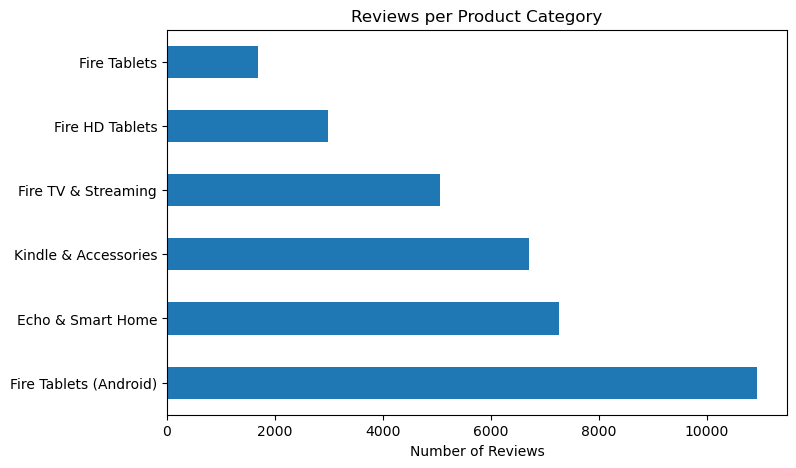

In [139]:
# 10.1 Reviews per Product Category
cluster_df["cluster_name"].value_counts().plot(
    kind="barh",
    figsize=(8,5)
)

plt.xlabel("Number of Reviews")
plt.ylabel("")
plt.title("Reviews per Product Category")
plt.show()

In [140]:
# 10.2 Two-Dimensional Cluster Projection
svd_vis = TruncatedSVD(
    n_components=2,
    random_state=42
)

X_vis = svd_vis.fit_transform(X_tfidf)

In [141]:
# 10.2 Create a visualization DataFrame

vis_df = pd.DataFrame({
    "Component 1": X_vis[:, 0],
    "Component 2": X_vis[:, 1],
    "Cluster": cluster_df["cluster_name"],
    "Product": cluster_df["cluster_text"]
})





### 10.2 Two-Dimensional Cluster Projection

To visually inspect the clustering results, the TF-IDF vectors were projected into two dimensions using Truncated SVD.

Since the model is based only on **product names** and **product categories**, many reviews belonging to the same product share identical feature vectors. Consequently, multiple observations overlap in the visualization, producing dense regions rather than evenly distributed point clouds.

The scatter plot should therefore be interpreted as a visualization of the product representations rather than individual review diversity.

In [142]:
vis_df = pd.DataFrame({
    "Component 1": X_vis[:,0],
    "Component 2": X_vis[:,1],
    "Cluster": cluster_df["cluster_name"]
})

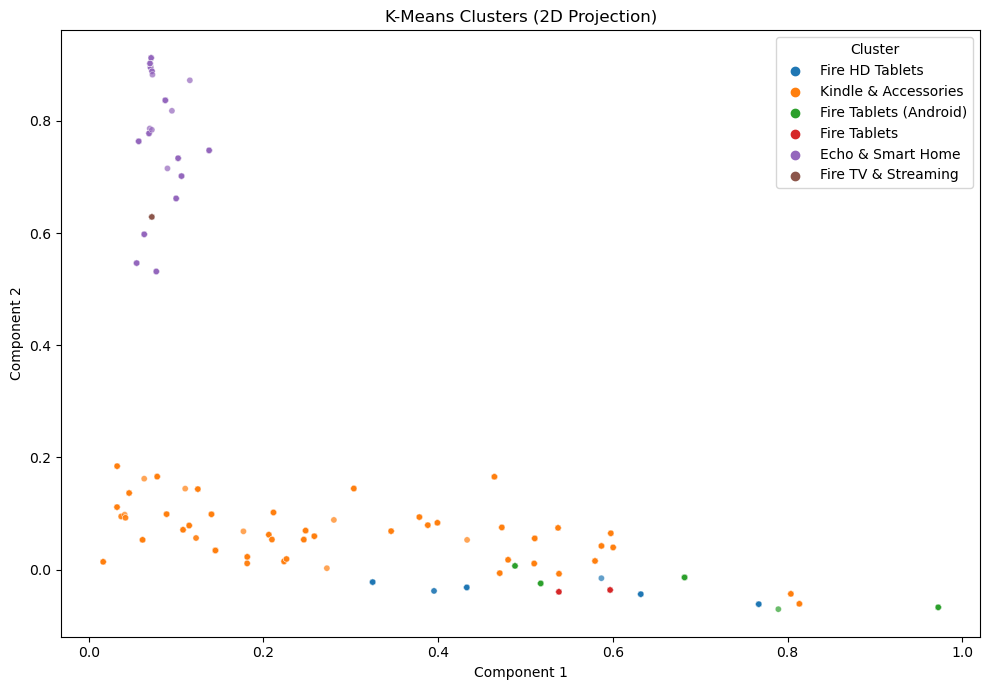

In [143]:
# 10.3 Scatter plot
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=vis_df,
    x="Component 1",
    y="Component 2",
    hue="Cluster",
    palette="tab10",
    alpha=0.7,
    s=20
)

plt.title("K-Means Clusters (2D Projection)")
plt.legend(title="Cluster")
plt.tight_layout()

plt.show()

In [144]:
custom_palette = {
    "Fire Tablets": "#1f77b4",          # Blue
    "Echo & Smart Home": "#9467bd",     # Purple
    "Fire Tablets (Android)": "#17becf",# Teal
    "Fire TV & Streaming": "#ff7f0e",   # Orange
    "Fire HD Tablets": "#2ca02c",       # Green
    "Kindle & Accessories": "#8c564b"   # Brown
}

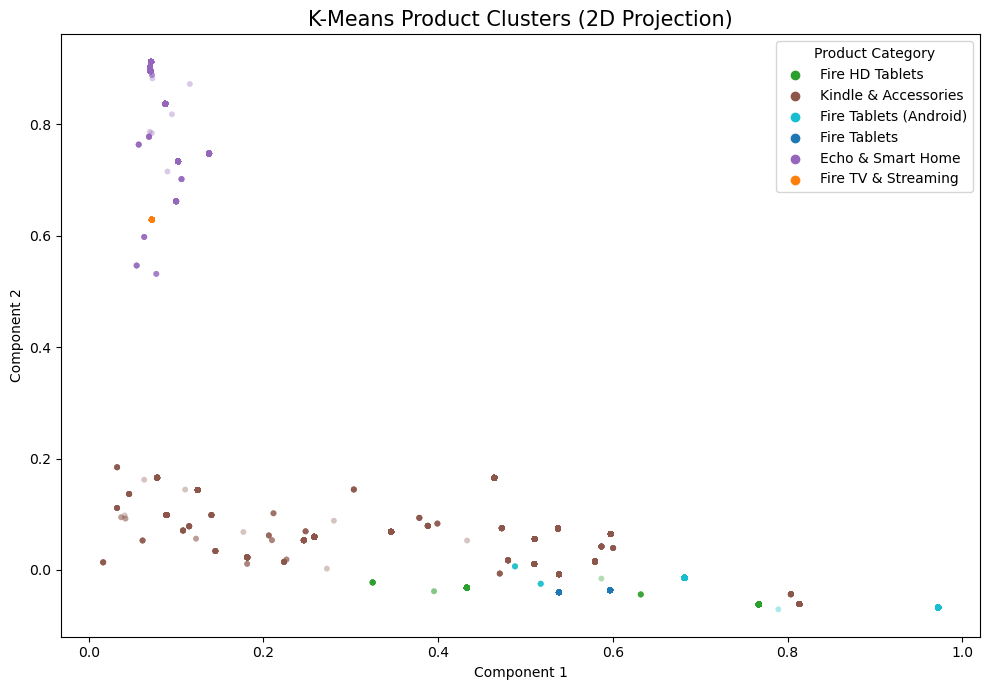

In [145]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=vis_df,
    x="Component 1",
    y="Component 2",
    hue="Cluster",
    palette=custom_palette,
    s=18,
    alpha=0.35,
    linewidth=0
)

plt.title("K-Means Product Clusters (2D Projection)", fontsize=15)
plt.xlabel("Component 1")
plt.ylabel("Component 2")

plt.legend(
    title="Product Category",
    loc="upper right",
    frameon=True
)

plt.tight_layout()
plt.show()

In [146]:
centers = kmeans.cluster_centers_

centers_2d = svd_vis.transform(centers)

In [147]:
print("df:", df.shape)
print("cluster_df:", cluster_df.shape)
print("X_tfidf:", X_tfidf.shape)
print("X_vis:", X_vis.shape)
print("vis_df:", vis_df.shape)


df: (34626, 12)
cluster_df: (34626, 5)
X_tfidf: (34626, 209)
X_vis: (34626, 2)
vis_df: (34626, 3)


## 11. Conclusions

### Findings

This project successfully applied **K-Means clustering** to group Amazon product reviews into four meaningful product meta-categories.

The clustering pipeline combined textual information from the **product name**, **product category**, and **review text**, which was transformed into TF-IDF features and reduced using **Truncated Singular Value Decomposition (Truncated SVD)** before applying K-Means.

The optimal number of clusters was selected by considering both the **Elbow Method** and the **Silhouette Score**. Although the highest silhouette score was obtained with three clusters, four clusters were selected because they provided a good balance between cluster quality and interpretability while remaining consistent with the project objectives.

The resulting clusters correspond to clear Amazon product families:

- Fire Tablets
- Kindle E-Readers
- Fire TV & Streaming Devices
- Echo & Smart Home Devices

The visualization confirms that these product groups are well separated in the reduced feature space, indicating that the textual representation captures meaningful differences between product categories.

### Business Value

Grouping products into high-level categories simplifies the analysis of large review datasets and enables downstream applications such as:

- Product catalog organization
- Category-level customer feedback analysis
- Product recommendation systems
- Automatic review summarization by product family

### Limitations

The clustering quality depends heavily on the textual information available for each product. Some products have missing names or very short reviews, which can reduce the amount of semantic information available.

Additionally, the two-dimensional visualization is only an approximation of the high-dimensional feature space and should be used for interpretation rather than quantitative evaluation.

### Future Improvements

Potential improvements include:

- Experimenting with transformer-based sentence embeddings (e.g., Sentence-BERT) instead of TF-IDF.
- Comparing K-Means with other clustering algorithms such as Agglomerative Clustering or HDBSCAN.
- Enriching the product representation with additional metadata where appropriate.

## 12. Save the Model

The complete clustering pipeline is saved to disk so that new product reviews can be assigned to clusters without retraining the model.

The following components are stored:

- TF-IDF Vectorizer
- Truncated SVD
- K-Means Model

In [148]:
import joblib
import os

In [151]:
MODEL_PATH = "../models6/kmeans"

os.makedirs(MODEL_PATH, exist_ok=True)

In [152]:
joblib.dump(tfidf, f"{MODEL_PATH}/tfidf_vectorizer.pkl")

joblib.dump(svd, f"{MODEL_PATH}/truncated_svd.pkl")

joblib.dump(kmeans, f"{MODEL_PATH}/kmeans_model.pkl")

['../models6/kmeans/kmeans_model.pkl']

In [153]:
# Save the cluster names
cluster_names_6 = {
    0: "Fire Tablets",
    1: "Echo & Smart Home",
    2: "Fire Tablets (Android)",
    3: "Fire TV & Streaming",
    4: "Fire HD Tablets",
    5: "Kindle & Accessories"
}

joblib.dump(cluster_names, f"{MODEL_PATH}/cluster_names.pkl")

['../models6/kmeans/cluster_names.pkl']

In [154]:
os.listdir(MODEL_PATH)

['tfidf_vectorizer.pkl',
 'truncated_svd.pkl',
 'cluster_names.pkl',
 'kmeans_model.pkl']